In [1]:
import matplotlib.pyplot as plt
import joblib as jlb
from collections import Counter
from sklearn.metrics import silhouette_score
from Algorithm import CLARANS
from pyclustering.utils import timedcall
from Dataprepare.data_processing import D,data_pca
from utils import clarans_fast_build,clarans_silhouette_analysis,clarans_davies_bouldin_analysis,clarans_Inertia_analysis

In [2]:
features=[
 'balance',
 'purchases',
 'cash_advance'
]
data=D[features].copy()
print(data.shape)
print(data.tail(1))

(8636, 3)
      balance  purchases  cash_advance
8635 -0.18053   0.707892       0.42096


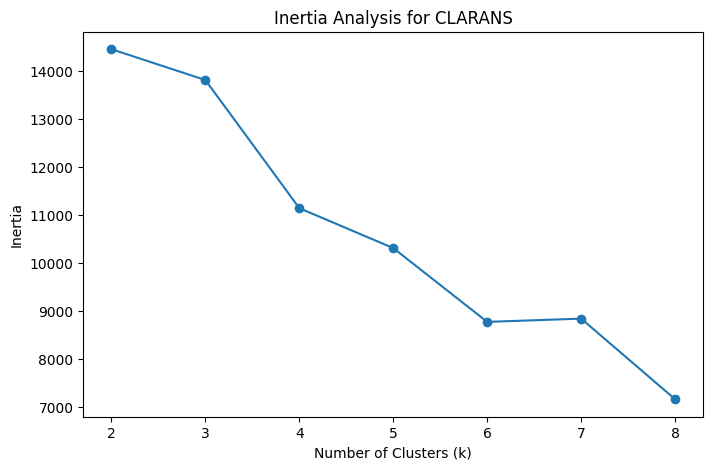

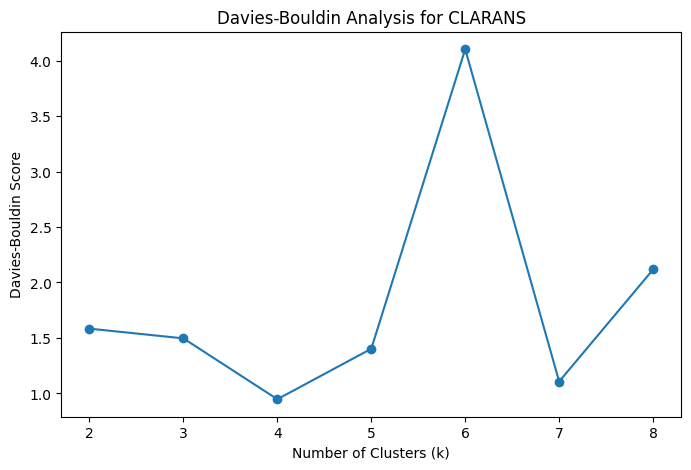

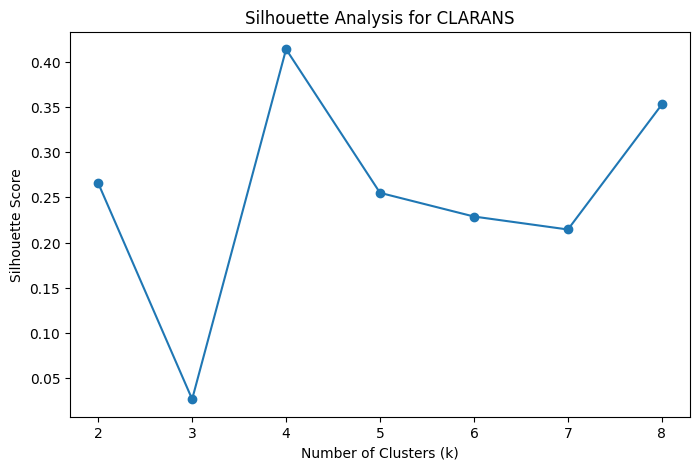

In [3]:
clarans_Inertia_analysis(data,[2,3,4,5,6,7,8],num_local=5,max_neighbors=5)
clarans_davies_bouldin_analysis(data,[2,3,4,5,6,7,8],num_local=5,max_neighbors=5)
clarans_silhouette_analysis(data,[2,3,4,5,6,7,8],num_local=5,max_neighbors=5)

In [5]:
#xay dung model clarans
k = 4
n_local=5
max_nei=5
Clarans_model = CLARANS(data, k, n_local, max_nei)
(ticks, result) = timedcall(Clarans_model.fit)
print(f"Time taken: {ticks:.4f} seconds")

Time taken: 0.0210 seconds


In [6]:
#lấy cluster và medoids
labels=Clarans_model.get_labels()
medoids = Clarans_model.get_medoids()

print("Labels:", labels)
print("Medoids:", medoids)

Labels: [2 3 2 ... 2 3 3]
Medoids: [[ 0.66001191  1.01479136  0.53055388]
 [ 0.79504041  0.95351183  0.58433789]
 [-0.02780411  1.21290016 -0.93789448]
 [-0.14872042  0.67449152  0.55925105]]


In [7]:
#gắn nhãn cluster đã có vào df
data['cluster'] = labels
print(data.head(5))
print('\nKích thước clusters:', Counter(labels))
print('\n2 clusters lớn nhất:', Counter(labels).most_common(2))

    balance  purchases  cash_advance  cluster
0 -1.334707  -0.123312     -0.937894        2
1  0.952729  -1.686451      1.518315        3
2  0.821135   0.589495     -0.937894        2
3  0.233137  -0.717052     -0.937894        2
4  0.651839   0.775749     -0.937894        2

Kích thước clusters: Counter({np.int64(2): 4400, np.int64(3): 2423, np.int64(1): 1657, np.int64(0): 156})

2 clusters lớn nhất: [(np.int64(2), 4400), (np.int64(3), 2423)]


In [8]:
#silhouette score
sil_score = silhouette_score(data.drop(columns=['cluster']), labels)
Clarans_model.sihouette_score_=sil_score
print(f'Silhouette Score: {Clarans_model.sihouette_score_:.4f}')

Silhouette Score: 0.2164


In [9]:
#luu model
jlb.dump(Clarans_model,'../customer_clustering/Output/clarans.mdl')

['../customer_clustering/Output/clarans.mdl']

In [10]:
#load model
Loaded_Clarans_model = jlb.load('../customer_clustering/Output/clarans.mdl')

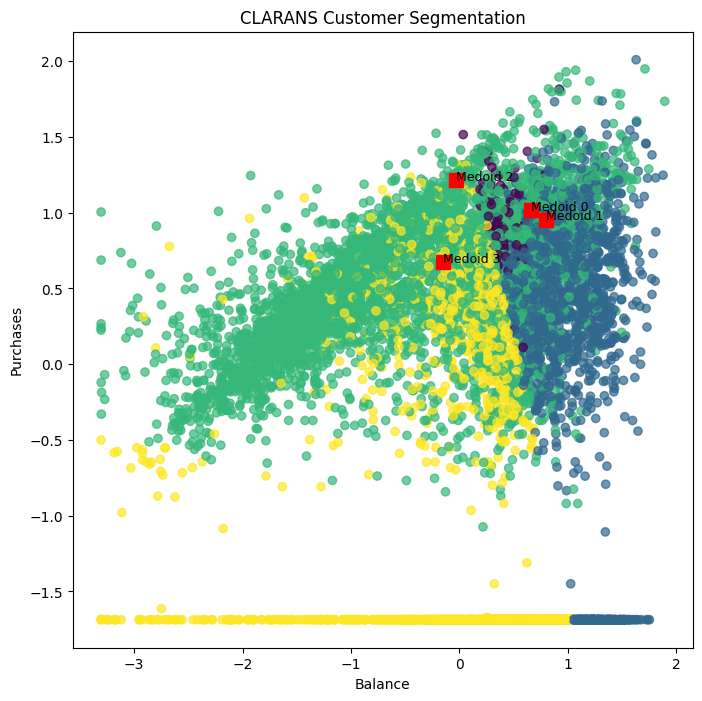

In [11]:
#hien thi model

plt.figure(figsize=(8,8))

plt.scatter(data['balance'],
            data['purchases'],
            c=data['cluster'], alpha=0.7)

for i, medoid in enumerate(medoids):
    plt.text(medoid[0], medoid[1], f'Medoid {i}', fontsize=9)
plt.scatter(medoids[:, 0],
            medoids[:, 1],
            marker='s',
            s=100,color='red'
            )

plt.xlabel("Balance")
plt.ylabel("Purchases")
plt.title("CLARANS Customer Segmentation")

plt.show()

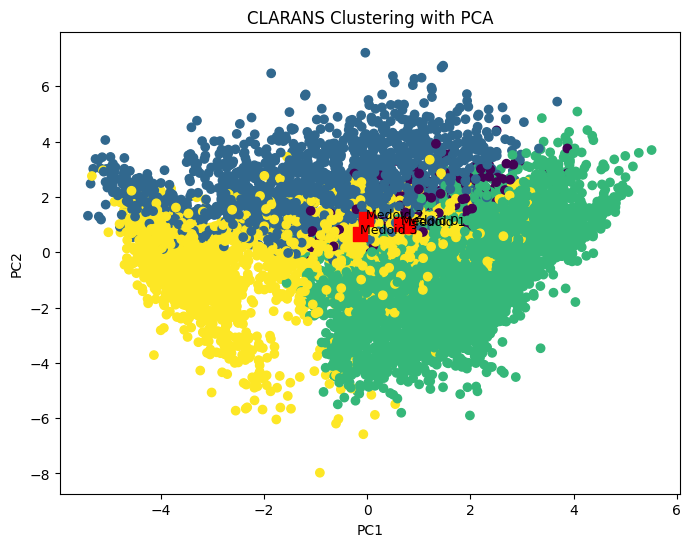

In [12]:

plt.figure(figsize=(8,6))
plt.scatter(data_pca[:,0], data_pca[:,1], c=labels)
plt.scatter(medoids[:, 0],
            medoids[:, 1],
            marker='s',
            s=100,color='red'
            )

for i, medoid in enumerate(medoids):
    plt.text(medoid[0], medoid[1], f'Medoid {i}', fontsize=9)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('CLARANS Clustering with PCA')
plt.show()

Silhouette Score: 0.2775


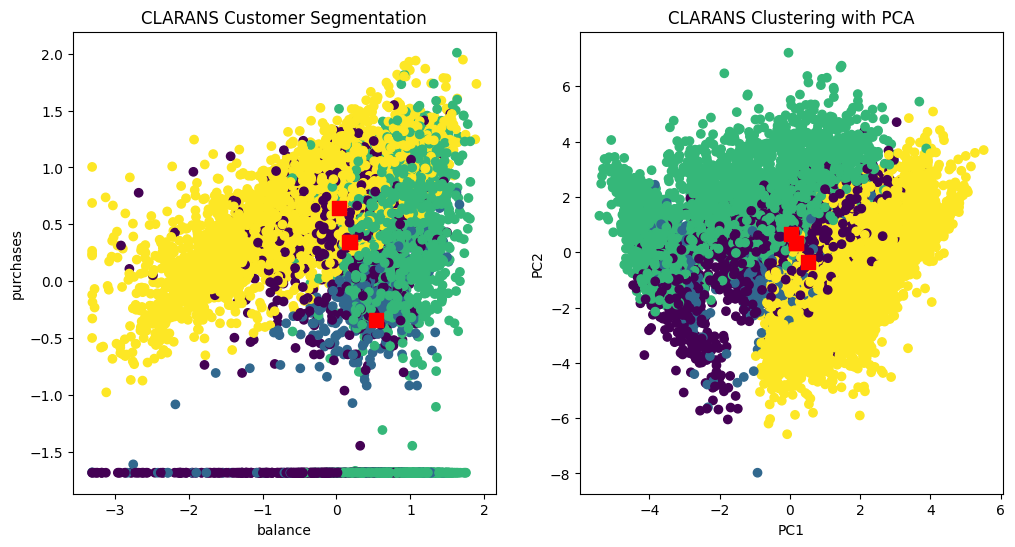

In [2]:
k = 4
n_local=5
max_nei=5
features=[
 'balance',
 'purchases',
 'cash_advance'
]
datafast=D[features].copy()
# clarans_silhouette_analysis(datafast,[2,3,4,5,6,7,8],num_local=5,max_neighbors=5)
clarans_fast_build(datafast,k,n_local,max_nei,'balance','purchases',data_pca)